In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from collections import Counter

In [2]:
os.getcwd()

'\\\\10.64.139.2\\data\\Temp - Please delete your files after copying\\billy\\figure\\fig1\\optosos pupation\\raw\\2023-11-28 topto, spok zopto\\Light\\stack'

In [3]:
all_pd = {}
for file in os.listdir(os.getcwd()):
    if file[-4:] == "xlsx":
        all_pd[file[:-5]]= pd.read_excel(file, sheet_name = "result_t", index_col = "Slice")

In [4]:
class condition():
    def __init__(self, y_value: list, x_time: list):
        self.name = self
        self.y = y_value
        self.x = x_time
        
def flatten(l):
    return [item for sublist in l for item in sublist]

def combine_setup(condition_lst: list):
    total_lst = []
    for con in condition_lst:
        total_lst.append(list(con.x))
    total_lst = flatten(total_lst)
    count = Counter(total_lst)
    combine_time = []
    for c in count:
        if count[c] == len(condition_lst):
            combine_time.append(c)
            
    y = {k:[] for k in combine_time}
    for con in condition_lst:
        for n, x in enumerate(con.x):
            if x in combine_time:
                y[x].append(con.y.iloc[n])
                
    mean_y = [list(y.keys()), [np.mean(y[k]) for k in y]]
    std_y = [list(y.keys()), [np.std(y[k]) for k in y]]
    return mean_y,std_y

In [5]:
all_data = {}
for file in all_pd:
    exp = all_pd[file].copy()
    if "dark" in file:
        exp.columns = flatten([all_pd[file].columns[:2], all_pd[file].columns[2:] + "-dark"])
    if "light" in file:
        exp.columns = flatten([all_pd[file].columns[:2], all_pd[file].columns[2:] + "-light"])

    for col in exp:
        if len(col) >5:
            t = exp["Date"]*24 + exp["Time"] - int(col.split("/")[0])*24 - int(col.split(" ")[1][0]) - 12
            setup = condition(exp[col], t)
            all_data[col] = setup

In [6]:
all_data.keys()

dict_keys(['28/11 3pm topto-dark', '28/11 7pm topto 1-dark', '28/11 7pm topto 2-dark', '29/11 7pm topto-dark', '30/11 7pm topto-dark', '29/11 7pm zopto spok-dark', '29/11 7pm W spok-dark', '28/11 3pm zopto spok-light', '28/11 7pm topto phm 1-light', '28/11 7pm topto phm 2-light', '28/11 7pm zopto spok 1-light', '28/11 7pm zopto spok 2-light', '28/11 7pm W spok 1-light', '28/11 7pm W spok 2-light', '29/11 3pm zopto spok-light', '29/11 7pm zopto spok-light', '29/11 7pm W spok-light', '30/11 7pm topto phm-light', '30/11 3pm zopto spok-light', '21/11 3pm egfr spok-light', '21/11 7pm egfr spok 1-light', '21/11 7pm topto Phm-light', '21/11 7pm egfr spok 2-light', '21/11 7pm W Phm-light', '22/11 3pm egfr spok-light', '22/11 3pm topto phm-light', '0/11 7pm PhmW-dark', '0/11 7pm zopto-dark', '0/11 7pm topto-dark', '1/11 3pm PhmW-dark', '1/11 3pm topto-dark', '1/11 3pm zopto-dark', '1/11 7pm PhmW-dark', '1/11 7pm zopto-dark', '1/11 7pm topto-dark', '2/11 3pm PhmW-dark', '2/11 3pm zopto-dark', '2

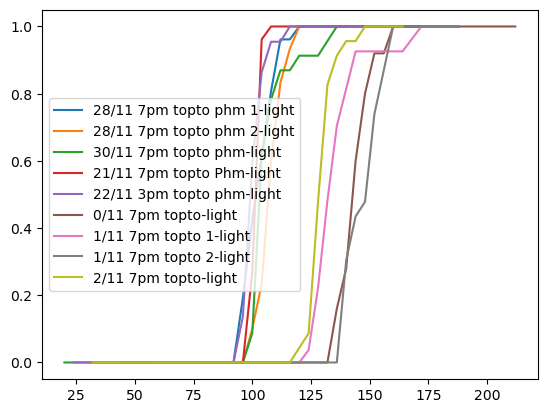

In [7]:
for l in all_data:
    if "topto" in l and "light" in l and not "spok" in l:
        plt.plot(all_data[l].x , all_data[l].y , label = l)

plt.legend()
plt.show()

In [8]:
labels_dict = {
    "PhmW-light":[v for v in all_data.keys() if "Phm" in v and "W" in v and "light" in v],
    "topto-light":[v for v in all_data.keys() if "topto" in v and not "spok" in v and  "light" in v],
    "zopto-light":[v for v in all_data.keys() if "zopto" in v and not "spok" in v and  "light" in v],
    "PhmW-dark":[v for v in all_data.keys() if "Phm" in v and "W" in v and "dark" in v],
    "topto-dark":[v for v in all_data.keys() if "topto" in v and not "spok" in v and "dark" in v],
    "zopto-dark":[v for v in all_data.keys() if "zopto" in v and not "spok" in v and "dark" in v],
}
labels_dict["topto-dark"]

['28/11 3pm topto-dark',
 '28/11 7pm topto 1-dark',
 '28/11 7pm topto 2-dark',
 '29/11 7pm topto-dark',
 '30/11 7pm topto-dark',
 '0/11 7pm topto-dark',
 '1/11 3pm topto-dark',
 '1/11 7pm topto-dark',
 '2/11 7pm topto-dark']

In [9]:
labels_dict["PhmW-dark"] = ['1/11 3pm PhmW-dark', '1/11 7pm PhmW-dark', '2/11 3pm PhmW-dark']
labels_dict["topto-light"] = ['28/11 7pm topto phm 1-light', '28/11 7pm topto phm 2-light', '30/11 7pm topto phm-light', '21/11 7pm topto Phm-light', '22/11 3pm topto phm-light']
labels_dict["topto-dark"] = ['28/11 3pm topto-dark', '28/11 7pm topto 1-dark', '28/11 7pm topto 2-dark', '29/11 7pm topto-dark', '30/11 7pm topto-dark']

In [10]:
labels_dict = {
    "PhmW-light":[v for v in all_data.keys() if "Phm" in v and "W" in v and "light" in v],
    "PhmW-dark":[v for v in all_data.keys() if "Phm" in v and "W" in v and "dark" in v],
    "topto-light":[v for v in all_data.keys() if "topto" in v and not "spok" in v and  "light" in v],
    "topto-dark":[v for v in all_data.keys() if "topto" in v and not "spok" in v and "dark" in v],
}
labels_dict["PhmW-dark"] = ['1/11 3pm PhmW-dark', '1/11 7pm PhmW-dark', '2/11 3pm PhmW-dark']
labels_dict["topto-light"] = ['28/11 7pm topto phm 1-light', '28/11 7pm topto phm 2-light', '30/11 7pm topto phm-light', '21/11 7pm topto Phm-light', '22/11 3pm topto phm-light']
labels_dict["topto-dark"] = ['28/11 3pm topto-dark', '28/11 7pm topto 1-dark', '28/11 7pm topto 2-dark', '29/11 7pm topto-dark', '30/11 7pm topto-dark']

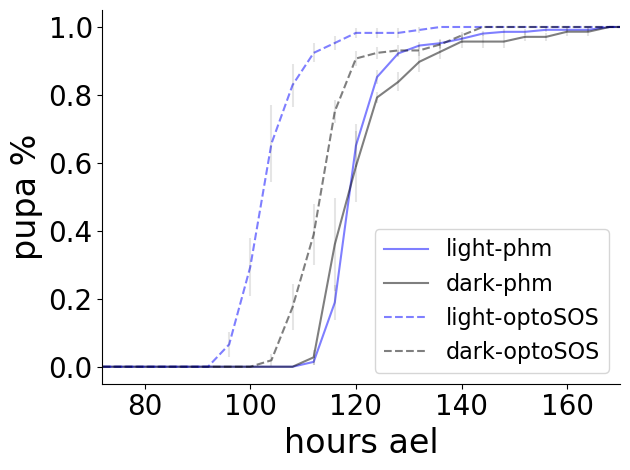

In [14]:
color_lst = ['b-', 'k-', 'b--', 'k--']

plt.rcParams['axes.titlesize'] = 28
plt.rcParams['axes.labelsize'] = 24
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 16

labels = ["light-phm", "dark-phm", "light-optoSOS",  "dark-optoSOS"]

for n, l in enumerate(labels_dict):
    y_mean, y_std = combine_setup([all_data[k] for k in all_data if k in labels_dict[l]])
    
    #to make sure everything equals to 1 (not accurate)
    y_mean[0].append(np.max(y_mean[0])+4)
    y_mean[1].append(1)
    y_std[1].append(0)

    y_mean[0].append(180)
    y_mean[1].append(1)
    y_std[1].append(0)
    df= pd.DataFrame(index=y_mean[0])
    df["mean"] = y_mean[1]
    df["stde"] = y_std[1]/np.sqrt(len(labels_dict[l]))
    df.index.name = "time"
    df.to_csv(f"{l}.csv")
    plt.plot(y_mean[0], y_mean[1], color_lst[n], label = labels[n], alpha = 0.5)
    plt.errorbar(y_mean[0], y_mean[1], yerr=y_std[1]/np.sqrt(len(labels_dict[l])), ecolor = (0,0,0,0.1), ls='none')

plt.xlim(72, 170)
plt.xlabel("hours ael")
plt.ylabel("pupa %")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.legend()
plt.tight_layout()
plt.savefig("topto pupation.png")
plt.show()


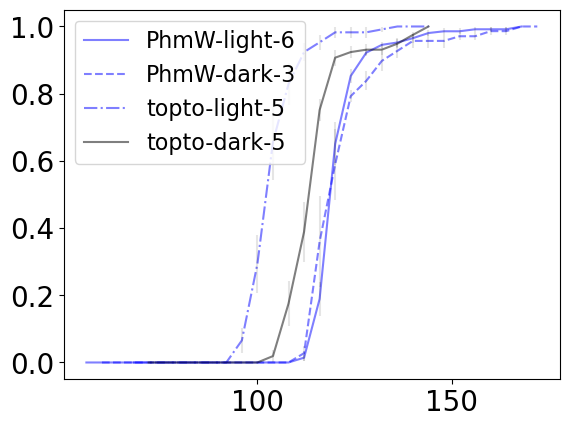

In [12]:
color_lst = ['b-', 'b--', 'b-.', 'k-', 'k--', 'k-.']

for n, l in enumerate(labels_dict):
    y_mean, y_std = combine_setup([all_data[k] for k in all_data if k in labels_dict[l]])
    
    #to make sure everything equals to 1 (not accurate)
    y_mean[0].append(np.max(y_mean[0])+4)
    y_mean[1].append(1)
    y_std[1].append(0)
    plt.plot(y_mean[0], y_mean[1], color_lst[n], label = l + "-" + str(len(labels_dict[l])), alpha = 0.5)
    plt.errorbar(y_mean[0], y_mean[1], yerr=y_std[1]/np.sqrt(len(labels_dict[l])), ecolor = (0,0,0,0.1), ls='none')


plt.legend()
plt.show()

#combine_setup([all_data[k] for k in all_data])

In [13]:
all_pd = {}
for file in os.listdir(os.getcwd()):
    if file[-4:] == "xlsx":
        all_pd[file[:-5]]= pd.read_excel(file, sheet_name = "result_ct", index_col = "Slice")

all_data = {}
for file in all_pd:
    exp = all_pd[file].copy()
    if "dark" in file:
        exp.columns = flatten([all_pd[file].columns[:2], all_pd[file].columns[2:] + "-dark"])
    if "light" in file:
        exp.columns = flatten([all_pd[file].columns[:2], all_pd[file].columns[2:] + "-light"])

    for col in exp:
        if len(col) >5:
            t = exp["Date"]*24 + exp["Time"] - int(col.split("/")[0])*24 - int(col.split(" ")[1][0]) - 12
            setup = condition(exp[col], t)
            all_data[col] = setup

ValueError: Worksheet named 'result_ct' not found

In [ ]:
def combine_sum(condition_lst: list):
    total_lst = []
    for con in condition_lst:
        total_lst.append(list(con.x))
    total_lst = flatten(total_lst)
    count = Counter(total_lst)
    combine_time = []
    for c in count:
        if count[c] == len(condition_lst):
            combine_time.append(c)
            
    y = {k:[] for k in combine_time}
    for con in condition_lst:
        for n, x in enumerate(con.x):
            if x in combine_time:
                y[x].append(con.y.iloc[n])
                
    sum_y = [list(y.keys()), [np.sum(y[k]) for k in y]]
    return sum_y

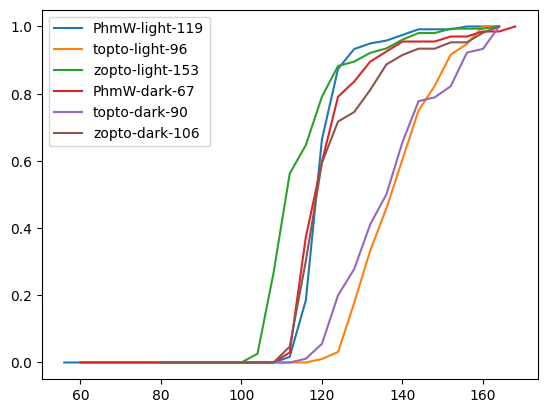

In [ ]:
for l in labels_dict:
    y_sum = combine_sum([all_data[k] for k in all_data if k in labels_dict[l]])
    y_s  = [y_sum[0], y_sum[1]/y_sum[1][-1]]
    plt.plot(y_s[0], y_s[1], label = l + f"-{str(y_sum[1][-1])}")


plt.legend()
plt.show()

In [ ]:
x_ = 